In [228]:
from xgboost import XGBRegressor, plot_importance
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import numpy as np


In [229]:
beetle_cv = pd.read_csv('./data/final_ds.csv')
beetle_cv = beetle_cv.sort_values(['Plotno', 'Date']).reset_index(drop=True)
beetle_cv['Plot_Area'] = pd.to_numeric(beetle_cv['Plot_Area'], errors='coerce', downcast='integer')
beetle_cv['Season'] = pd.to_numeric(beetle_cv['Season'], errors='coerce', downcast='integer')
beetle_cv.drop(columns=['Unnamed: 0.1','crs', 'NDVI_diff', 'SI', 'Date', 'sensor', 'Plot_Area'], inplace=True)
beetle_cv.reset_index(drop=True, inplace=True)

for var in ['d2m', 'ssrd', 't2m', 'tp', 'spei']:
    for lag in [1, 3, 7]:
        beetle_cv[f'{var}_lag{lag}'] = beetle_cv[var].shift(lag)

for var in ['d2m', 'ssrd', 't2m', 'tp', 'spei']:
    beetle_cv[f'{var}_roll3'] =  beetle_cv[var].shift(1).rolling(3).mean().astype('float32')

beetle_cv.dropna(inplace=True)
beetle_cv

,Plotno,Season,Proportion_of_Norway_spruce,Lon,Lat,d2m,ssrd,t2m,tp,spei,...,tp_lag3,tp_lag7,spei_lag1,spei_lag3,spei_lag7,d2m_roll3,ssrd_roll3,t2m_roll3,tp_roll3,spei_roll3
7,1,3.0,80.0,17.243780,62.389525,280.44410,8821968.0,286.55927,7.087029e-06,0.558825,...,3.284944e-04,9.701577e-03,-0.897959,-1.173253,1.350244,281.748383,6974673.50,285.394989,0.000219,-1.081488
8,1,3.0,80.0,17.243780,62.389525,280.44410,8821968.0,286.55927,7.087029e-06,0.558825,...,3.284944e-04,9.701577e-03,0.558825,-1.173253,1.350244,281.394073,7785545.00,286.043671,0.000112,-0.504129
9,1,3.0,80.0,17.243780,62.389525,280.44410,8821968.0,286.55927,7.087029e-06,0.558825,...,3.242108e-07,9.701577e-03,0.558825,-0.897959,1.350244,281.039795,8596416.00,286.692352,0.000005,0.073231
13,2,2.0,90.0,16.391673,63.291876,282.45764,5589969.0,285.63843,2.476620e-05,1.174121,...,3.644371e-03,3.242108e-07,0.920911,0.920911,-0.897959,279.996063,4450397.00,281.080139,0.003644,0.920911
14,2,1.0,90.0,16.391673,63.291876,282.45764,5589969.0,285.63843,2.476620e-05,1.174121,...,3.644371e-03,7.087029e-06,1.174121,0.920911,0.558825,280.816589,4830254.50,282.599579,0.002438,1.005314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2085,211,3.0,80.0,18.190458,63.331373,280.83997,2912150.0,281.56520,2.333676e-04,-0.083460,...,2.726705e-03,5.172792e-05,-0.585424,0.920911,-0.295843,280.498291,5041913.00,283.018555,0.002138,0.418799
2086,211,2.0,80.0,18.190458,63.331373,280.83997,2912150.0,281.56520,2.333676e-04,-0.083460,...,3.685037e-03,5.172792e-05,-0.083460,0.920911,-0.295843,281.027985,4756912.50,282.841736,0.001307,0.084009
2087,211,2.0,80.0,18.190458,63.331373,280.83997,2912150.0,281.56520,2.333676e-04,-0.083460,...,2.126023e-06,5.172792e-05,-0.083460,-0.585424,-0.295843,281.331085,4213509.50,282.997803,0.000156,-0.250781
2099,215,4.0,80.0,15.747468,62.401910,280.76526,7766764.0,284.32410,7.486901e-07,-0.246319,...,2.153282e-03,9.143780e-07,0.396865,0.958961,-0.264468,283.042297,2746925.25,283.991302,0.004223,0.584230


In [230]:
X = beetle_cv.drop(columns='NDVI_after')
y = beetle_cv['NDVI_after']


In [231]:
X_train_list = []
X_test_list = []
y_train_list = []
y_test_list = []
test_indices = []      
train_indices = []

for plot in beetle_cv['Plotno'].unique():
    plot_data = beetle_cv[beetle_cv['Plotno'] == plot].sort_index()  # or sort by a date column if you have one
    split_idx = int(len(plot_data) * 0.8)  # 80% train, 20% test
    
    X_train_list.append(plot_data.iloc[:split_idx].drop(columns=['NDVI_after', 'Plotno', 'Lat', 'Lon']))
    X_test_list.append(plot_data.iloc[split_idx:].drop(columns=['NDVI_after', 'Plotno', 'Lat', 'Lon']))
    
    y_train_list.append(plot_data.iloc[:split_idx]['NDVI_after'])
    y_test_list.append(plot_data.iloc[split_idx:]['NDVI_after'])

    # store row indices
    train_indices.extend(plot_data.iloc[:split_idx].index.tolist())
    test_indices.extend(plot_data.iloc[split_idx:].index.tolist())

X_train = pd.concat(X_train_list)
X_test = pd.concat(X_test_list)
y_train = pd.concat(y_train_list)
y_test = pd.concat(y_test_list)

In [232]:
xgb_regressor = XGBRegressor()
xgb_regressor.fit(X_train, y_train)
y_pred = xgb_regressor.predict(X_test)

MSE: 0.00567871840071031
R squared: 0.8792848695879881


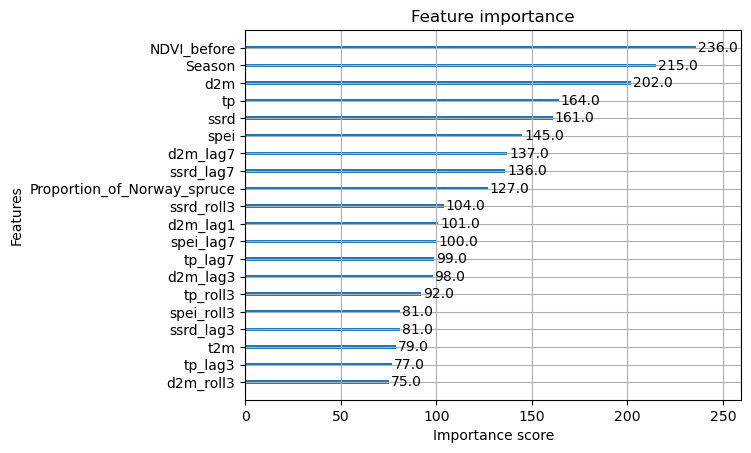

In [233]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

r2 = r2_score(y_test, y_pred)
print("R squared:", r2)

plot_importance(xgb_regressor, importance_type='weight', max_num_features=20)
plt.show()

In [234]:
y_pred = xgb_regressor.predict(X.drop(columns=['Lat', 'Lon', 'Plotno']))

In [235]:
beetle_cv['NDVI_pred'] = y_pred

# Assume NDVI_diff = NDVI_after - NDVI_before
beetle_cv['NDVI_diff'] = beetle_cv['NDVI_pred'] - beetle_cv['NDVI_before']


pixel_area_m2 = 10 * 10
beetle_cv['damaged_area_m2'] = beetle_cv['NDVI_diff'].apply(lambda x: max(0, -x)) * pixel_area_m2
beetle_cv['damaged_area_cost'] = beetle_cv['damaged_area_m2'] * 1200
beetle_cv.reset_index(inplace=True)
beetle_cv

,index,Plotno,Season,Proportion_of_Norway_spruce,Lon,Lat,d2m,ssrd,t2m,tp,...,spei_lag7,d2m_roll3,ssrd_roll3,t2m_roll3,tp_roll3,spei_roll3,NDVI_pred,NDVI_diff,damaged_area_m2,damaged_area_cost
0,7,1,3.0,80.0,17.243780,62.389525,280.44410,8821968.0,286.55927,7.087029e-06,...,1.350244,281.748383,6974673.50,285.394989,0.000219,-1.081488,0.577211,0.518158,0.000000,0.000000
1,8,1,3.0,80.0,17.243780,62.389525,280.44410,8821968.0,286.55927,7.087029e-06,...,1.350244,281.394073,7785545.00,286.043671,0.000112,-0.504129,0.576714,0.517661,0.000000,0.000000
2,9,1,3.0,80.0,17.243780,62.389525,280.44410,8821968.0,286.55927,7.087029e-06,...,1.350244,281.039795,8596416.00,286.692352,0.000005,0.073231,0.468947,0.409894,0.000000,0.000000
3,13,2,2.0,90.0,16.391673,63.291876,282.45764,5589969.0,285.63843,2.476620e-05,...,-0.897959,279.996063,4450397.00,281.080139,0.003644,0.920911,0.242553,-0.131925,13.192522,15831.026731
4,14,2,1.0,90.0,16.391673,63.291876,282.45764,5589969.0,285.63843,2.476620e-05,...,0.558825,280.816589,4830254.50,282.599579,0.002438,1.005314,0.243084,-0.131394,13.139429,15767.315327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1528,2085,211,3.0,80.0,18.190458,63.331373,280.83997,2912150.0,281.56520,2.333676e-04,...,-0.295843,280.498291,5041913.00,283.018555,0.002138,0.418799,0.044579,-0.147187,14.718740,17662.488214
1529,2086,211,2.0,80.0,18.190458,63.331373,280.83997,2912150.0,281.56520,2.333676e-04,...,-0.295843,281.027985,4756912.50,282.841736,0.001307,0.084009,0.047616,-0.144150,14.414959,17297.950528
1530,2087,211,2.0,80.0,18.190458,63.331373,280.83997,2912150.0,281.56520,2.333676e-04,...,-0.295843,281.331085,4213509.50,282.997803,0.000156,-0.250781,0.094748,-0.097018,9.701840,11642.207496
1531,2099,215,4.0,80.0,15.747468,62.401910,280.76526,7766764.0,284.32410,7.486901e-07,...,-0.264468,283.042297,2746925.25,283.991302,0.004223,0.584230,0.168678,-0.122726,12.272551,14727.061591


In [ ]:
out_df = beetle_cv[['Lat','Lon', 'd2m', 'ssrd', 't2m', 'tp', 'spei', 'NDVI_pred', 
                    'NDVI_diff', 'damaged_area_m2', 'damaged_area_cost']]

json_dict = out_df.to_dict(orient="index")

import json

with open("output.json", "w") as f:
    json.dump(json_dict, f, indent=2)